In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
url = "https://api.worldbank.org/v2/country/ARE/indicator/SI.RMT.COST.IB.ZS?format=json&per_page=100"
response = requests.get(url)
data = response.json()

In [3]:
print(len(data))
print(data[0])

2
{'page': 1, 'pages': 1, 'per_page': 100, 'total': 66, 'sourceid': '2', 'lastupdated': '2026-07-13'}


In [4]:
print(data[1][0])
print(data[1][1])

{'indicator': {'id': 'SI.RMT.COST.IB.ZS', 'value': 'Average transaction cost of sending remittances to a specific country (%)'}, 'country': {'id': 'AE', 'value': 'United Arab Emirates'}, 'countryiso3code': 'ARE', 'date': '2025', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 2}
{'indicator': {'id': 'SI.RMT.COST.IB.ZS', 'value': 'Average transaction cost of sending remittances to a specific country (%)'}, 'country': {'id': 'AE', 'value': 'United Arab Emirates'}, 'countryiso3code': 'ARE', 'date': '2024', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 2}


In [5]:
import os
etherscan_api_key = os.environ.get("ETHERSCAN_API_KEY")

In [6]:
usdc_contract = "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48"
url = f"https://api.etherscan.io/v2/api?chainid=1&module=account&action=tokentx&contractaddress={usdc_contract}&page=1&offset=1000&sort=desc&apikey={etherscan_api_key}"
response = requests.get(url)
eth_data = response.json()

In [7]:
tx_list = eth_data['result']

In [8]:
print(eth_data['status'])
print(eth_data['message'])
print(eth_data['result'][0])

1
OK
{'blockNumber': '25838970', 'timeStamp': '1787742287', 'hash': '0xb24ac48f090c0e7919f553385c453d65937706e296cb6d6c1ecec31ef761ef33', 'nonce': '8399', 'blockHash': '0x52a7b95fe7ef93554b5200f4054b6966735ee6ef1b9944d16286c9d61cf6c6da', 'from': '0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45', 'contractAddress': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48', 'to': '0x2c2226a6381e68a86c1a8dcb8d9fdab050959dd5', 'value': '189909259', 'tokenName': 'USDC', 'tokenSymbol': 'USDC', 'tokenDecimal': '6', 'transactionIndex': '294', 'gas': '255941', 'gasPrice': '70879769', 'gasUsed': '164926', 'cumulativeGasUsed': '25307773', 'input': 'deprecated', 'methodId': '0x5ae401dc', 'functionName': 'multicall(uint256 deadline, bytes[] data)', 'confirmations': '1', 'statusRep': '1'}


In [9]:
for tx in eth_data['result'][:5]:
    print(tx['gasPrice'])
    print(tx['timeStamp'])

values = [int(tx['value']) for tx in eth_data['result']]
print(max(values))
senders = [tx['from'] for tx in eth_data['result']]
print(len(set(senders)))

70879769
1787742287
70879769
1787742287
70879769
1787742287
70879769
1787742287
70879769
1787742287
101881304575619
600


In [10]:
print(len(eth_data['result']))
tx_list = eth_data['result']

1000


In [11]:
gas_used = []

for tx in tx_list:
    gas_used.append(int(tx['gasUsed']))

In [12]:
print(len(gas_used))
print(gas_used[:5])

1000
[164926, 164926, 168808, 168808, 198242]


In [13]:
gas_price = []

for tx in tx_list:
     gas_price.append(int(tx['gasPrice']))

timestamps = []

for tx in tx_list:
     timestamps.append(int(tx['timeStamp']))

In [14]:
print(len(gas_price))
print(gas_price[:5])

print(len(timestamps))
print(timestamps[:5])

1000
[70879769, 70879769, 70879769, 70879769, 70879769]
1000
[1787742287, 1787742287, 1787742287, 1787742287, 1787742287]


In [15]:
df = pd.DataFrame({'timestamp': timestamps, 'gas_price_wei': gas_price, 'gas_used': gas_used})

In [16]:
print(len(gas_used))
print(len(gas_price))
print(len(timestamps))


1000
1000
1000


In [17]:
df['fee_wei'] = df['gas_used'] * df['gas_price_wei']

In [18]:
print(df[['gas_used', 'gas_price_wei', 'fee_wei']].head())

   gas_used  gas_price_wei         fee_wei
0    164926       70879769  11689916782094
1    164926       70879769  11689916782094
2    168808       70879769  11965072045352
3    168808       70879769  11965072045352
4    198242       70879769  14051347166098


In [19]:
url = "https://api.coingecko.com/api/v3/simple/price?ids=ethereum&vs_currencies=usd"
response = requests.get(url)
eth_price_data = response.json()
print(eth_price_data)

{'ethereum': {'usd': 2470.25}}


In [20]:
eth_price_usd = eth_price_data['ethereum']['usd']
print(eth_price_usd)

2470.25


In [21]:
df['fee_usd'] = (df['fee_wei'] / 1e18) * eth_price_usd
df['date'] = pd.to_datetime(df['timestamp'], unit='s')

In [22]:
print(df[['date', 'gas_used', 'fee_usd']].head())
print(df['fee_usd'].describe())

                 date  gas_used   fee_usd
0 2026-08-26 11:04:47    164926  0.028877
1 2026-08-26 11:04:47    164926  0.028877
2 2026-08-26 11:04:47    168808  0.029557
3 2026-08-26 11:04:47    168808  0.029557
4 2026-08-26 11:04:47    198242  0.034710
count    1000.000000
mean        0.446854
std         0.814424
min         0.006612
25%         0.053712
50%         0.167022
75%         0.535823
max         6.119019
Name: fee_usd, dtype: float64


In [23]:
values = []
for tx in tx_list:
    values.append(int(tx['value']) / 1_000_000)
df['value_usdc'] = values

In [24]:
print(df[['value_usdc', 'fee_usd']].describe())
df['fee_pct_of_value'] = (df['fee_usd'] / df['value_usdc']) * 100
large_txns = df[df['value_usdc'] > 10000]
print(large_txns[['value_usdc', 'fee_usd', 'fee_pct_of_value']].describe())

         value_usdc      fee_usd
count  1.000000e+03  1000.000000
mean   2.396047e+05     0.446854
std    4.599937e+06     0.814424
min    0.000000e+00     0.006612
25%    2.437500e-04     0.053712
50%    4.445806e+01     0.167022
75%    5.269549e+02     0.535823
max    1.018813e+08     6.119019
         value_usdc    fee_usd  fee_pct_of_value
count  6.200000e+01  62.000000      6.200000e+01
mean   3.855500e+06   0.154866      5.844623e-04
std    1.823078e+07   0.208552      1.188638e-03
min    1.000447e+04   0.006612      1.891793e-07
25%    1.780687e+04   0.015409      2.902209e-05
50%    3.824467e+04   0.035889      8.400694e-05
75%    9.687246e+04   0.243536      5.378441e-04
max    1.018813e+08   0.766737      7.055140e-03


In [25]:
traditional_banking = {
    'median_speed_hours' : 2,
    'pct_within_1_business_day': 92.7,
    'cost_pct_of_value': 0.5
}

mbridge = {
    'settlement_speed': 'instant',
    'pilot_value_usd': 22100000,
    'pilot_transaction_count': 164
}

print(traditional_banking)
print(mbridge)

{'median_speed_hours': 2, 'pct_within_1_business_day': 92.7, 'cost_pct_of_value': 0.5}
{'settlement_speed': 'instant', 'pilot_value_usd': 22100000, 'pilot_transaction_count': 164}


In [26]:
import scienceplots
plt.style.use(['science', 'no-latex'])

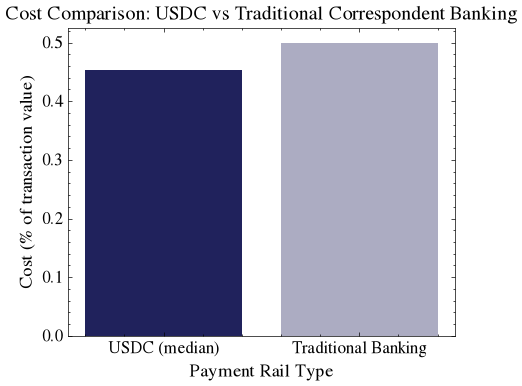

In [27]:
usdc_median_fee_pct = df['fee_pct_of_value'].median()

cost_labels = ['USDC (median)', 'Traditional Banking']
cost_values = [usdc_median_fee_pct, 0.5]

plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 13

colors = ['#20225C', '#ACACC2']

plt.figure(figsize=(5, 4))
plt.bar(cost_labels, cost_values, color=colors)
plt.ylabel('Cost (% of transaction value)')
plt.xlabel('Payment Rail Type')
plt.title('Cost Comparison: USDC vs Traditional Correspondent Banking')
plt.show()

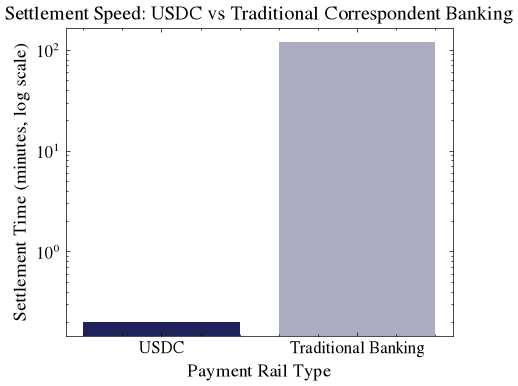

In [28]:
traditional_minutes = traditional_banking['median_speed_hours'] * 60
usdc_seconds = 12
usdc_minutes = usdc_seconds / 60

speed_labels = ['USDC', 'Traditional Banking']
speed_values = [usdc_minutes, traditional_minutes]

plt.figure(figsize=(5, 4))
plt.bar(speed_labels, speed_values, color=colors)
plt.yscale('log')
plt.ylabel('Settlement Time (minutes, log scale)')
plt.xlabel('Payment Rail Type')
plt.title('Settlement Speed: USDC vs Traditional Correspondent Banking')

plt.show()

In [29]:

df = df[df['value_usdc'] >= 1]
print(f"Transactions retained: {len(df)} of 1000")
print(df['fee_pct_of_value'].describe())

Transactions retained: 663 of 1000
count    6.630000e+02
mean     1.558813e+00
std      6.304308e+00
min      1.891793e-07
25%      6.325480e-03
50%      4.668389e-02
75%      4.438378e-01
max      7.879246e+01
Name: fee_pct_of_value, dtype: float64


In [30]:
print(df['fee_pct_of_value'].describe())

count    6.630000e+02
mean     1.558813e+00
std      6.304308e+00
min      1.891793e-07
25%      6.325480e-03
50%      4.668389e-02
75%      4.438378e-01
max      7.879246e+01
Name: fee_pct_of_value, dtype: float64
